# Confidence Interval
    A Confidence Interval is a range of values that is likely to contain the true population parameter.

    Instead of estimating a population parameter using a single value, a Confidence Interval provides an interval within which the true value is expected to lie.

    Confidence Intervals help quantify the uncertainty associated with sample estimates.

    Instead of saying
        "The average salary is ₹52,000."

    we say
        "We are 95% confident that the average salary lies between ₹50,800 and ₹53,200."



### Point Estimate
    A Point Estimate is a single numerical value calculated from a sample that is used to estimate a population parameter.

    Ex:-
        - Sample Mean estimates Population Mean.
        - Sample Variance estimates Population Variance.


### Confidence Level
    The Confidence Level represents the percentage of confidence that the interval estimation procedure captures the true population parameter over repeated sampling.

    Common Confidence Levels are
        - 90%
        - 95%
        - 99%

    Higher Confidence Levels produce wider intervals because greater confidence requires a larger range.

### Margin of Error
    Margin of Error represents the maximum expected difference between the sample estimate and the true population parameter.

    A larger Margin of Error produces a wider Confidence Interval.

    A smaller Margin of Error produces a narrower Confidence Interval.

                                                        ME = Z * SE


### Components of a Confidence Interval
    Lower Limit
            The smallest value of the interval.

    Upper Limit
            The largest value of the interval.

    Sample Mean
            The center of the interval.

    Margin of Error
        The distance from the sample mean to either limit.

### CI For Z Proceture
$$
CI=\bar{x}\pm Z\left(\frac{\sigma}{\sqrt{n}}\right)
$$

where

- $\bar{x}$ = Sample Mean
- $Z$ = Critical Value
- $\sigma$ = Population Standard Deviation
- $n$ = Sample Size

### Use the Z-Procedure when

- The population standard deviation $(\sigma)$ is known.
- The sample size is large $(n \ge 30)$.
- The observations are randomly selected.
- The observations are independent.

### Common Z Values

| Confidence Level | Alpha (α) | Z Critical Value |
|------------------|-----------|------------------|
| 90% | 0.10 | 1.645 |
| 95% | 0.05 | 1.960 |
| 99% | 0.01 | 2.576 |

### CI For T Procedure

$$
CI=\bar{x}\pm t\left(\frac{s}{\sqrt{n}}\right)
$$

### where

- $\bar{x}$ = Sample Mean
- $t$ = t Critical Value
- $s$ = Sample Standard Deviation
- $n$ = Sample Size

### Use the t-Procedure when

- The population standard deviation is unknown.
- The sample standard deviation is used.
- The sample is randomly selected.
- The observations are independent.
- The sample size is small, typically less than 30.
- n > 30 if it not normal then use CLT To make Normal.
- Distribution looks like a Normal Distribution but it is not a Normal Distribution.(It's Called Student's Distribution)

######
- The t-distribution depends on the Degrees of Freedom.
$$
df=n-1
$$


### Common t Value
    commonly used t critical values for two-sided Confidence Intervals.

| Degrees of Freedom | 90% CI | 95% CI | 99% CI |
|-------------------:|-------:|--------:|--------:|
| 5 | 2.015 | 2.571 | 4.032 |
| 10 | 1.812 | 2.228 | 3.169 |
| 15 | 1.753 | 2.131 | 2.947 |
| 20 | 1.725 | 2.086 | 2.845 |
| 25 | 1.708 | 2.060 | 2.787 |
| 30 | 1.697 | 2.042 | 2.750 |
| 40 | 1.684 | 2.021 | 2.704 |
| 60 | 1.671 | 2.000 | 2.660 |
| 120 | 1.658 | 1.980 | 2.617 |
| ∞ (Infinite) | 1.645 | 1.960 | 2.576 |

### Observation
    As the Degrees of Freedom increase,
        - the t critical value decreases,
        - the t-distribution becomes closer to the Standard Normal Distribution,
        - for very large samples, the t-distribution is almost identical to the Z-distribution.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as sts

In [6]:
sample_mean = 50000

population_std = 8000

sample_size = 100

z = 1.96

SE = population_std / np.sqrt(sample_size)

ME = z * SE

lower = sample_mean - ME

upper = sample_mean + ME

print(f"Sample Mean      : {sample_mean:.2f}")

print(f"Standard Error   : {SE:.2f}")

print(f"Margin of Error  : {ME:.2f}")

print(f"95% Confidence Interval Range: ({lower:.2f} - {upper:.2f})")

Sample Mean      : 50000.00
Standard Error   : 800.00
Margin of Error  : 1568.00
95% Confidence Interval Range: (48432.00 - 51568.00)


In [7]:
CI = pd.DataFrame({

    "Statistic":[
                "Sample Mean",
                "Standard Error",
                "Margin of Error",
                "Lower Limit",
                "Upper Limit"
            ],

    "Value":[
            sample_mean,
            SE,
            ME,
            lower,
            upper
    ]

})

CI.round(2)

,Statistic,Value
0,Sample Mean,50000.0
1,Standard Error,800.0
2,Margin of Error,1568.0
3,Lower Limit,48432.0
4,Upper Limit,51568.0


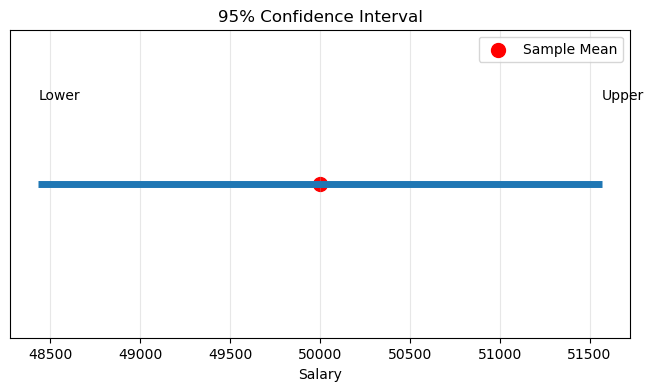

In [23]:
plt.figure(figsize=(8,4))
plt.hlines(
        y=1,
        xmin=lower,
        xmax=upper,
        linewidth=5
        )

plt.scatter(
        sample_mean,
        1,
        color="red",
        s=100,
        label="Sample Mean"
        )

plt.text(lower,1.03,"Lower")

plt.text(upper,1.03,"Upper")

plt.yticks([])

plt.xlabel("Salary")

plt.title("95% Confidence Interval")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [24]:
np.random.seed(42)

Employees = pd.DataFrame({
    "Employee_ID": range(1,1001),
    "Monthly_Salary": np.random.randint( 25000,120001,1000 )

})

Employees.head()

,Employee_ID,Monthly_Salary
0,1,40795
1,2,25860
2,3,101820
3,4,79886
4,5,31265


In [25]:
sample = Employees.sample( n=100,random_state=42 )


sample.head()

,Employee_ID,Monthly_Salary
521,522,95588
737,738,107844
740,741,70445
660,661,59578
411,412,56024


In [26]:
sample_mean = sample["Monthly_Salary"].mean()

population_std = Employees["Monthly_Salary"].std(ddof=0)

sample_size = len(sample)

print(f"Sample Mean : {sample_mean:.2f}")

print(f"Population Standard Deviation : {population_std:.2f}")

print(f"Sample Size : {sample_size}")

Sample Mean : 66304.12
Population Standard Deviation : 28151.60
Sample Size : 100


### Standard Error

In [28]:
SE = population_std / np.sqrt(sample_size)

print(f"Standard Error : {SE:.2f}")

Standard Error : 2815.16


### Margin Of Error

In [29]:
z = 1.96

ME = z * SE

print(f"Margin of Error : {ME:.2f}")

Margin of Error : 5517.71


### Confidence Interval

In [31]:
lower = sample_mean - ME

upper = sample_mean + ME

print(f"95% Confidence Interval : ({lower:.2f} - {upper:.2f})")

95% Confidence Interval : (60786.41 - 71821.83)


In [32]:
CI = pd.DataFrame({
    "Statistic":[
            "Sample Mean",
            "Standard Error",
            "Margin of Error",
            "Lower Limit",
            "Upper Limit"
    ],

    "Value":[
        sample_mean,
        SE,
        ME,
        lower,
        upper
    ]
})

CI.round(2)

,Statistic,Value
0,Sample Mean,66304.12
1,Standard Error,2815.16
2,Margin of Error,5517.71
3,Lower Limit,60786.41
4,Upper Limit,71821.83


### Confidence Interval Using SciPy
    Python provides built-in functions to calculate Confidence Intervals.
    

In [35]:
from scipy.stats import norm

confidence=0.95

interval = norm.interval(

    confidence,

    loc=sample_mean,

    scale=SE

)

print(interval)

(np.float64(60786.5086475367), np.float64(71821.73135246329))


In [36]:
confidence_levels = [90,95,99]

z_values = [1.645,1.96,2.576]

comparison = []

for confidence,z in zip(confidence_levels,z_values):

    ME = z * SE

    lower = sample_mean - ME

    upper = sample_mean + ME

    comparison.append( [ confidence,z, ME, lower, upper ])

comparison = pd.DataFrame(
                    comparison,

                    columns=[
                        "Confidence Level",
                        "Z Value",
                        "Margin of Error",
                        "Lower Limit",
                        "Upper Limit"
    ]

)

comparison.round(2)

,Confidence Level,Z Value,Margin of Error,Lower Limit,Upper Limit
0,90,1.64,4630.94,61673.18,70935.06
1,95,1.96,5517.71,60786.41,71821.83
2,99,2.58,7251.85,59052.27,73555.97


### CI Using t Procedure

In [5]:
train = pd.read_csv(r"C:\Users\SANDESH\titanic_Data\train.csv")

test=pd.read_csv(r"C:\Users\SANDESH\titanic_Data\test.csv")

In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train.shape

(891, 12)

In [8]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
test.shape

(418, 11)

In [18]:
df=pd.concat([train,test]).sample(1309)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
285,1177,NaN,3,"Dennis, Mr. William",male,36.0,0,0,A/5 21175,7.250,NaN,S
360,361,0.0,3,"Skoog, Mr. Wilhelm",male,40.0,1,4,347088,27.900,NaN,S
649,650,1.0,3,"Stanley, Miss. Amy Zillah Elsie",female,23.0,0,0,CA. 2314,7.550,NaN,S
757,758,0.0,2,"Bailey, Mr. Percy Andrew",male,18.0,0,0,29108,11.500,NaN,S
729,730,0.0,3,"Ilmakangas, Miss. Pieta Sofia",female,25.0,1,0,STON/O2. 3101271,7.925,NaN,S


In [17]:
df.shape

(1309, 12)

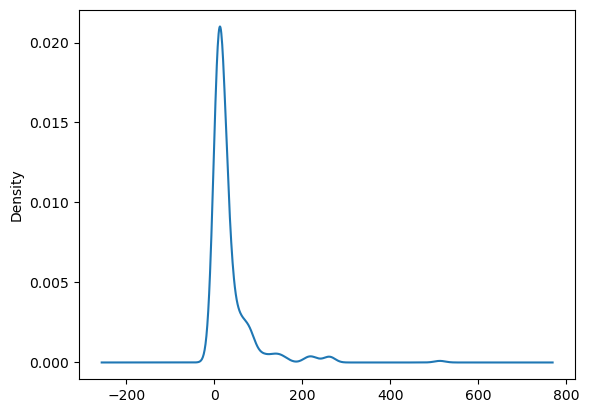

In [20]:
df['Fare'].plot(kind='kde')

plt.show()

In [21]:
Samples=[]
Stds=[]
for i in range(100):
    x=df['Fare'].dropna().sample(30).values
    Stds.append(x.std())
    Samples.append(x.tolist())

In [25]:
Samples=np.array(Samples)

### Sampling Mean of Sampling Distribition

In [36]:
Sampling_mean=Samples.mean(axis=1)
Sampling_mean

array([31.80722   , 38.73125333, 47.05194667, 47.41667   , 33.21763667,
       38.99694   , 16.75611   , 39.26778   , 43.03167   , 30.03680667,
       44.41875333, 32.39180333, 26.09791333, 49.71986   , 34.33986333,
       30.03736   , 28.75805333, 48.01138667, 31.48889   , 36.93847333,
       37.23903   , 41.47152333, 47.27361667, 45.45666667, 34.00347   ,
       43.49833   , 30.36444667, 27.30569667, 31.15944667, 30.57069667,
       25.98180667, 24.97374667, 37.0875    , 45.52055333, 28.20777667,
       28.52818667, 27.20389   , 16.41638333, 27.50861   , 18.59167   ,
       46.17083   , 35.30764   , 28.05444667, 34.83694667, 55.23347333,
       27.43472333, 31.27666667, 29.32222   , 37.62444333, 34.44333   ,
       54.99833667, 25.52083333, 32.25374333, 32.30721667, 31.88361333,
       36.60500333, 39.11791667, 35.66513667, 40.79097333, 35.71166667,
       28.25389   , 31.16124667, 22.05722667, 39.9693    , 29.69346667,
       38.875     , 42.75013667, 45.45902667, 49.87903   , 36.08

In [35]:
Sam_STD=np.mean(Stds)
Sam_STD

np.float64(48.34666804047404)

### We Make Normal Using CLT

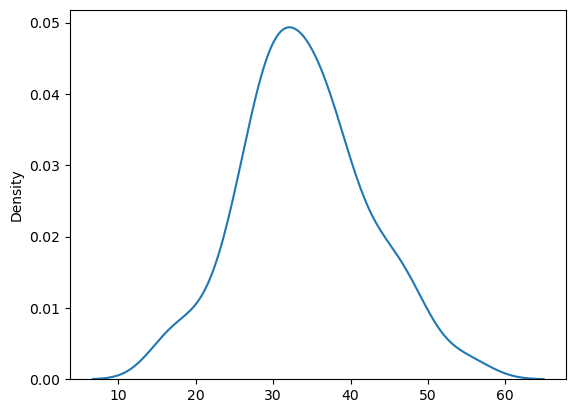

In [31]:
sns.kdeplot(Sampling_mean)
plt.show()

In [33]:
Sampling_mean.mean()

np.float64(34.036631566666664)

In [40]:
Sampling_mean.std()/np.sqrt(30)

np.float64(1.4793881713131614)

In [41]:
Sam_STD/np.sqrt(30)

np.float64(8.82685355532724)

### Finding CI At 90% Confedence Level
    90% = 2.042 Value get form t Tabale Online

In [42]:
lower_limit=Sampling_mean.mean() - 2.042 *(Sam_STD/np.sqrt(30))

upper_limit=Sampling_mean.mean() + 2.042 *(Sam_STD/np.sqrt(30))

In [43]:
print("The CI Range Is",lower_limit,"-",upper_limit)

The CI Range Is 16.01219660668844 - 52.061066526644886


### Actual Pop Mean

In [45]:
df['Fare'].mean()

np.float64(33.29547928134557)

### At 50% Confedent Level
    Confedence Reduces Then Confendece Interval Also Reduces

In [47]:
lower_limit=Sampling_mean.mean() - 0.683 *(Sam_STD/np.sqrt(30))

upper_limit=Sampling_mean.mean() + 0.683 *(Sam_STD/np.sqrt(30))

In [48]:
print("The CI Range Is",lower_limit,"-",upper_limit)

The CI Range Is 28.00789058837816 - 40.06537254495517
